# Klasifikasi Komentar Judol (Judi Online)

Model untuk mendeteksi komentar spam judol di YouTube menggunakan Machine Learning.

**2 Pendekatan:**
1. TF-IDF + Traditional ML (Logistic Regression, Naive Bayes, Random Forest)
2. LSTM Deep Learning

## 1. Import Libraries

In [20]:
pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import joblib
import warnings
warnings.filterwarnings('ignore')

# Deep Learning
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

print(f'TensorFlow version: {tf.__version__}')

TensorFlow version: 2.20.0


## 2. Load Dataset

In [60]:
ensemble_path = '../datasets/comments_labeled_ensemble.csv'
final_path = '../datasets/comments_labeled_final.csv'

if os.path.exists(ensemble_path):
    file_path = ensemble_path
elif os.path.exists(final_path):
    file_path = final_path
else:
    file_path = None

if file_path:
    df = pd.read_csv(file_path)
    print(f"Dataset yang digunakan: {file_path}")
    print(f"Total data: {len(df)}")
    print(f"Kolom: {df.columns.tolist()}")
    print(df.head())
else:
    print("ERROR: Tidak ada dataset yang ditemukan!")

Dataset yang digunakan: ../datasets/comments_labeled_ensemble.csv
Total data: 79295
Kolom: ['video_id', 'author', 'comment_text', 'published_at', 'like_count', 'is_promo', 'ai_prob', 'label', 'ensemble_pred', 'ensemble_prob']
      video_id               author  \
0  YZ4N8jH5R_M  @HermanHerman-tp1us   
1  YZ4N8jH5R_M          @zallesvhan   
2  YZ4N8jH5R_M   @tedivirgiawan9996   
3  YZ4N8jH5R_M             @entah02   
4  YZ4N8jH5R_M      @FandyFandy-u7d   

                                        comment_text          published_at  \
0  Maaf bang tapi sekarang km udah gak natural ba...  2025-11-15T23:20:20Z   
1  Kontennya keren! Terus berkarya bang 🙌\r\nSala...  2025-11-14T09:21:34Z   
2              Giliran yg lucu waktu nya cepet bngt😢  2025-11-12T16:07:14Z   
3                                Eh ada Pak jalal 😂😂  2025-11-12T12:39:29Z   
4  Sekilas anakNya jarwo mirip te ocah yh..tau cM...  2025-11-12T05:44:36Z   

   like_count  is_promo   ai_prob  label  ensemble_pred  ensemble_prob

Distribusi Label:
ensemble_pred
0    74797
1     4498
Name: count, dtype: int64

Persentase Judol: 5.67%


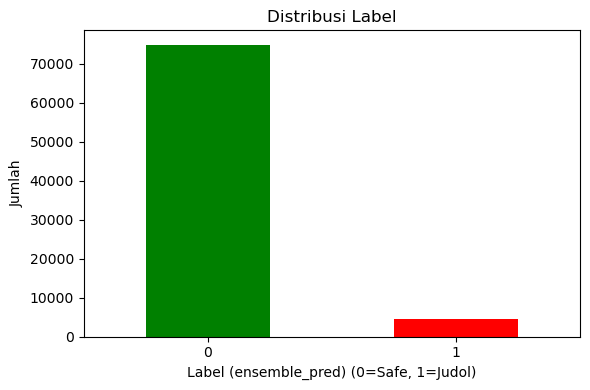

In [ ]:
label_col = 'ensemble_pred' if 'comments_labeled_ensemble.csv' in file_path else 'label'

print('Distribusi Label:')
print(df[label_col].value_counts())
print(f"\nPersentase Judol: {df[label_col].mean()*100:.2f}%")

plt.figure(figsize=(6, 4))
df[label_col].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Distribusi Label')
plt.xlabel(f'Label ({label_col}) (0=Safe, 1=Judol)')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. Preprocessing

In [67]:
df = df.dropna(subset=['comment_text', label_col])

X = df['comment_text'].astype(str)
y = df[label_col].astype(int)

print(f'Total samples: {len(X)}')
print(f'Judol (1): {y.sum()}')
print(f'Safe (0): {len(y) - y.sum()}')


Total samples: 79295
Judol (1): 4498
Safe (0): 74797


In [69]:
# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {len(X_train)}')
print(f'Test set: {len(X_test)}')

Training set: 63436
Test set: 15859


---
# PART A: TF-IDF + Traditional ML
---

## 4. Feature Extraction (TF-IDF)

In [70]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 3),
    analyzer='char_wb',
    min_df=2,
    max_df=0.95
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f'Vocabulary size: {len(tfidf.vocabulary_)}')
print(f'Train shape: {X_train_tfidf.shape}')

Vocabulary size: 10000
Train shape: (63436, 10000)


## 5. Train TF-IDF Models

In [71]:
# Logistic Regression
print('Training Logistic Regression...')
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_model.fit(X_train_tfidf, y_train)
y_pred_lr = lr_model.predict(X_test_tfidf)
print(f'Accuracy: {accuracy_score(y_test, y_pred_lr):.4f} | F1: {f1_score(y_test, y_pred_lr):.4f}')

Training Logistic Regression...
Accuracy: 0.9804 | F1: 0.8466


In [72]:
# Naive Bayes
print('Training Naive Bayes...')
nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train_tfidf, y_train)
y_pred_nb = nb_model.predict(X_test_tfidf)
print(f'Accuracy: {accuracy_score(y_test, y_pred_nb):.4f} | F1: {f1_score(y_test, y_pred_nb):.4f}')

Training Naive Bayes...
Accuracy: 0.9829 | F1: 0.8378


In [73]:
# Random Forest
print('Training Random Forest...')
rf_model = RandomForestClassifier(n_estimators=100, max_depth=50, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_train_tfidf, y_train)
y_pred_rf = rf_model.predict(X_test_tfidf)
print(f'Accuracy: {accuracy_score(y_test, y_pred_rf):.4f} | F1: {f1_score(y_test, y_pred_rf):.4f}')

Training Random Forest...
Accuracy: 0.9764 | F1: 0.7405


## 6. Confusion Matrix - TF-IDF Models

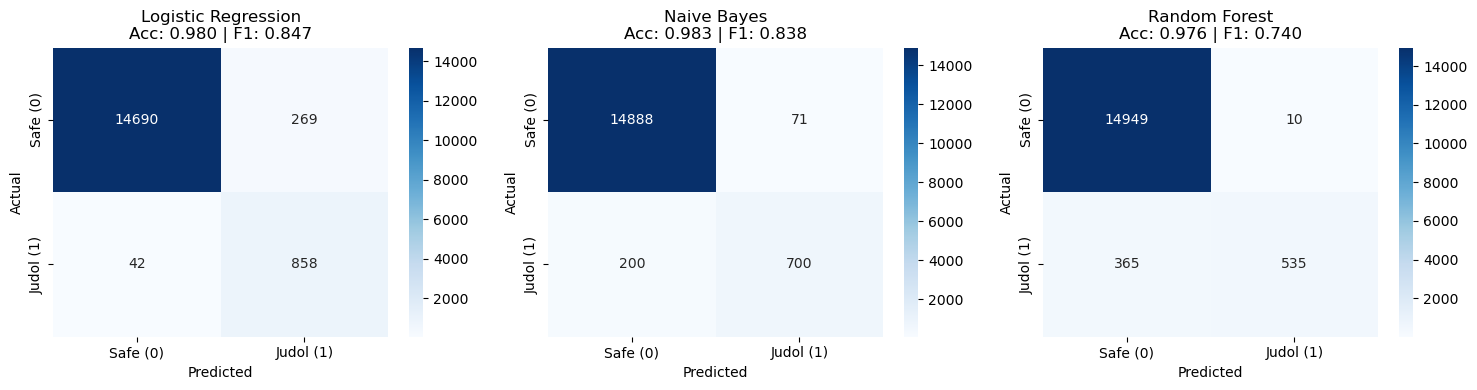

In [74]:
# Plot confusion matrix untuk semua TF-IDF models
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models_tfidf = [
    ('Logistic Regression', y_pred_lr),
    ('Naive Bayes', y_pred_nb),
    ('Random Forest', y_pred_rf)
]

for ax, (name, y_pred) in zip(axes, models_tfidf):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Safe (0)', 'Judol (1)'],
                yticklabels=['Safe (0)', 'Judol (1)'])
    ax.set_title(f'{name}\nAcc: {accuracy_score(y_test, y_pred):.3f} | F1: {f1_score(y_test, y_pred):.3f}')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

In [77]:
# Classification Report - Best TF-IDF Model
print('=== Classification Report: Logistic Regression ===')
print(classification_report(y_test, y_pred_lr, target_names=['Safe (0)', 'Judol (1)']))

=== Classification Report: Logistic Regression ===
              precision    recall  f1-score   support

    Safe (0)       1.00      0.98      0.99     14959
   Judol (1)       0.76      0.95      0.85       900

    accuracy                           0.98     15859
   macro avg       0.88      0.97      0.92     15859
weighted avg       0.98      0.98      0.98     15859



---
# PART B: LSTM Deep Learning
---

## 7. Tokenization untuk LSTM

In [78]:
# Hyperparameters
MAX_WORDS = 20000
MAX_LEN = 100
EMBEDDING_DIM = 128

# Tokenizer
tokenizer = Tokenizer(num_words=MAX_WORDS, char_level=False, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# Convert to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Padding
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

print(f'Vocabulary size: {len(tokenizer.word_index)}')
print(f'Train shape: {X_train_pad.shape}')

Vocabulary size: 66864
Train shape: (63436, 100)


## 8. Build & Train LSTM Model

In [79]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print(f'Class weights: {class_weight_dict}')

Class weights: {0: np.float64(0.530064507503593), 1: np.float64(8.815453029460812)}


In [80]:
# Build Bidirectional LSTM model
lstm_model = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(32)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [81]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history = lstm_model.fit(
    X_train_pad, y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.1,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

print(f'\nTraining stopped at epoch: {len(history.history["loss"])}')

Epoch 1/100
893/893 ━━━━━━━━━━━━━━━━━━━━ 152s 160ms/step - accuracy: 0.9150 - loss: 0.2537 - val_accuracy: 0.9726 - val_loss: 0.0895
Epoch 2/100
893/893 ━━━━━━━━━━━━━━━━━━━━ 143s 160ms/step - accuracy: 0.9749 - loss: 0.0923 - val_accuracy: 0.9696 - val_loss: 0.0777
Epoch 3/100
893/893 ━━━━━━━━━━━━━━━━━━━━ 155s 174ms/step - accuracy: 0.9874 - loss: 0.0514 - val_accuracy: 0.9768 - val_loss: 0.0890
Epoch 4/100
893/893 ━━━━━━━━━━━━━━━━━━━━ 178s 199ms/step - accuracy: 0.9894 - loss: 0.0439 - val_accuracy: 0.9732 - val_loss: 0.0939
Epoch 5/100
893/893 ━━━━━━━━━━━━━━━━━━━━ 155s 173ms/step - accuracy: 0.9922 - loss: 0.0326 - val_accuracy: 0.9749 - val_loss: 0.0990
Epoch 6/100
893/893 ━━━━━━━━━━━━━━━━━━━━ 166s 186ms/step - accuracy: 0.9929 - loss: 0.0283 - val_accuracy: 0.9782 - val_loss: 0.0800
Epoch 7/100
893/893 ━━━━━━━━━━━━━━━━━━━━ 160s 180ms/step - accuracy: 0.9947 - loss: 0.0284 - val_accuracy: 0.9582 - val_loss: 0.1432
Epoch 7: early stopping
Restoring model weights from the end of the b

## 9. Training Metrics Table (Loss, Accuracy, Val_Loss, Val_Acc)

In [82]:
metrics_df = pd.DataFrame({
    'Epoch': range(1, len(history.history['loss']) + 1),
    'Loss': history.history['loss'],
    'Accuracy': history.history['accuracy'],
    'Val_Loss': history.history['val_loss'],
    'Val_Accuracy': history.history['val_accuracy']
})

print('=== LSTM Training Metrics per Epoch ===')
print(metrics_df.to_string(index=False))

best_epoch = metrics_df['Val_Loss'].idxmin() + 1
print(f'\nBest Epoch (lowest val_loss): {best_epoch}')
print(metrics_df.iloc[best_epoch-1])

=== LSTM Training Metrics per Epoch ===
 Epoch     Loss  Accuracy  Val_Loss  Val_Accuracy
     1 0.253664  0.915014  0.089455      0.972573
     2 0.092282  0.974918  0.077657      0.969578
     3 0.051433  0.987406  0.088982      0.976829
     4 0.043891  0.989403  0.093862      0.973203
     5 0.032640  0.992241  0.098963      0.974937
     6 0.028348  0.992924  0.080027      0.978247
     7 0.028449  0.994658  0.143241      0.958228

Best Epoch (lowest val_loss): 2
Epoch           2.000000
Loss            0.092282
Accuracy        0.974918
Val_Loss        0.077657
Val_Accuracy    0.969578
Name: 1, dtype: float64


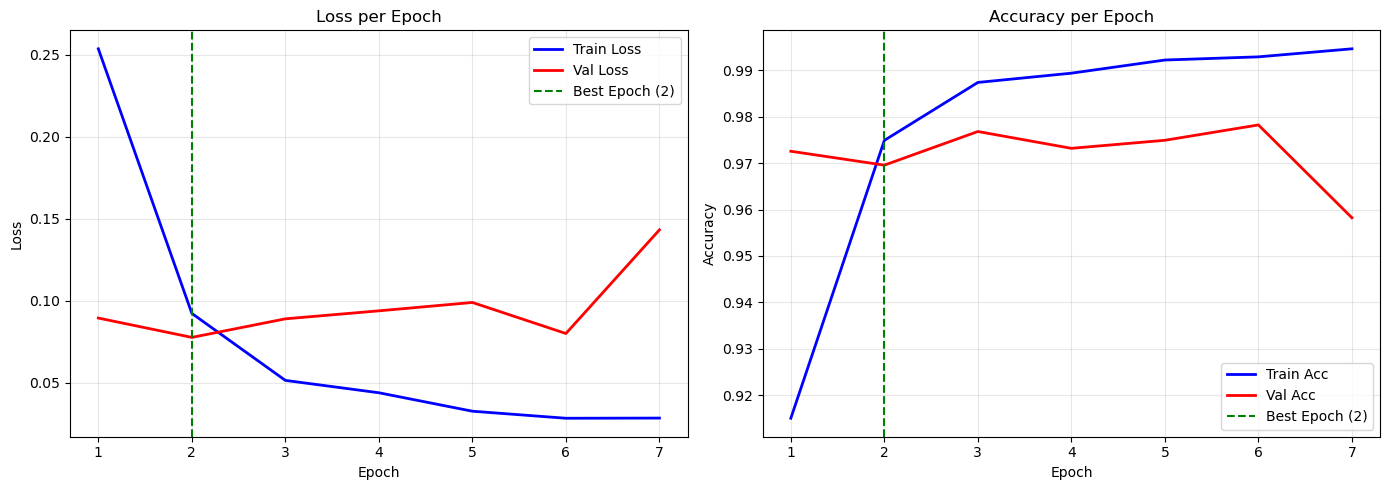

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(metrics_df['Epoch'], metrics_df['Loss'], 'b-', label='Train Loss', linewidth=2)
axes[0].plot(metrics_df['Epoch'], metrics_df['Val_Loss'], 'r-', label='Val Loss', linewidth=2)
axes[0].axvline(x=best_epoch, color='g', linestyle='--', label=f'Best Epoch ({best_epoch})')
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(metrics_df['Epoch'], metrics_df['Accuracy'], 'b-', label='Train Acc', linewidth=2)
axes[1].plot(metrics_df['Epoch'], metrics_df['Val_Accuracy'], 'r-', label='Val Acc', linewidth=2)
axes[1].axvline(x=best_epoch, color='g', linestyle='--', label=f'Best Epoch ({best_epoch})')
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Evaluate LSTM & Confusion Matrix

In [85]:
y_pred_lstm_prob = lstm_model.predict(X_test_pad)
y_pred_lstm = (y_pred_lstm_prob > 0.5).astype(int).flatten()

print(f'LSTM Accuracy: {accuracy_score(y_test, y_pred_lstm):.4f}')
print(f'LSTM F1-Score: {f1_score(y_test, y_pred_lstm):.4f}')

496/496 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step
LSTM Accuracy: 0.9740
LSTM F1-Score: 0.7976


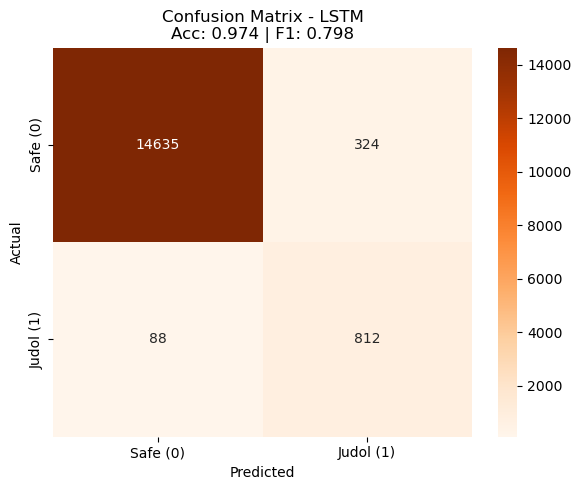


=== Classification Report: LSTM ===
              precision    recall  f1-score   support

    Safe (0)       0.99      0.98      0.99     14959
   Judol (1)       0.71      0.90      0.80       900

    accuracy                           0.97     15859
   macro avg       0.85      0.94      0.89     15859
weighted avg       0.98      0.97      0.98     15859



In [86]:
plt.figure(figsize=(6, 5))
cm_lstm = confusion_matrix(y_test, y_pred_lstm)
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Safe (0)', 'Judol (1)'],
            yticklabels=['Safe (0)', 'Judol (1)'])
plt.title(f'Confusion Matrix - LSTM\nAcc: {accuracy_score(y_test, y_pred_lstm):.3f} | F1: {f1_score(y_test, y_pred_lstm):.3f}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print('\n=== Classification Report: LSTM ===')
print(classification_report(y_test, y_pred_lstm, target_names=['Safe (0)', 'Judol (1)']))

---
# Comparison: All Models
---

In [87]:
# Compare all models
results = [
    {'Model': 'Logistic Regression', 'Accuracy': accuracy_score(y_test, y_pred_lr), 'F1-Score': f1_score(y_test, y_pred_lr)},
    {'Model': 'Naive Bayes', 'Accuracy': accuracy_score(y_test, y_pred_nb), 'F1-Score': f1_score(y_test, y_pred_nb)},
    {'Model': 'Random Forest', 'Accuracy': accuracy_score(y_test, y_pred_rf), 'F1-Score': f1_score(y_test, y_pred_rf)},
    {'Model': 'Bidirectional LSTM', 'Accuracy': accuracy_score(y_test, y_pred_lstm), 'F1-Score': f1_score(y_test, y_pred_lstm)},
]

results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False)
print('\n=== MODEL COMPARISON ===')
print(results_df.to_string(index=False))


=== MODEL COMPARISON ===
              Model  Accuracy  F1-Score
Logistic Regression  0.980390  0.846571
        Naive Bayes  0.982912  0.837822
 Bidirectional LSTM  0.974021  0.797642
      Random Forest  0.976354  0.740484


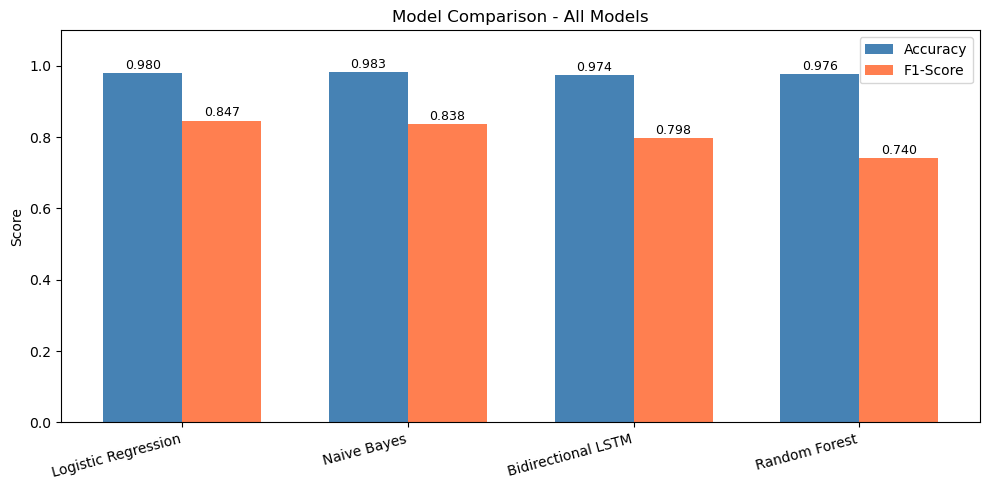

In [88]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results_df))
width = 0.35

bars1 = ax.bar(x - width/2, results_df['Accuracy'], width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, results_df['F1-Score'], width, label='F1-Score', color='coral')

ax.set_ylabel('Score')
ax.set_title('Model Comparison - All Models')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=15, ha='right')
ax.legend()
ax.set_ylim(0, 1.1)

for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 11. Save Models

In [89]:
import os
os.makedirs('../models', exist_ok=True)

joblib.dump(lr_model, '../models/judol_logreg_model.pkl')
joblib.dump(tfidf, '../models/tfidf_vectorizer.pkl')

lstm_model.save('../models/judol_lstm_model.keras')
joblib.dump(tokenizer, '../models/lstm_tokenizer.pkl')

print('All models saved!')

All models saved!


## 12. Test Inference

In [90]:
def predict_tfidf(text):
    X = tfidf.transform([text])
    pred = lr_model.predict(X)[0]
    prob = lr_model.predict_proba(X)[0][1]
    return pred, prob

def predict_lstm(text):
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=MAX_LEN, padding='post')
    prob = lstm_model.predict(pad, verbose=0)[0][0]
    pred = 1 if prob > 0.5 else 0
    return pred, prob

# Test
test_comments = [
    'Video bagus bang, lanjutkan!',
    'Gaskeun join di MINI1221 banyak bonus!',
    'Buruan join di 𝐏𝐀𝐒𝐓𝐄𝟒𝐃 banyak cuan!',
    '2,8rb subs skrng pasti bakalan jutaan subs smangat',
    'Semangat terus kak, kontennya bagus!',
]

print('\n=== PREDICTION TEST ===')
print('-' * 80)
for comment in test_comments:
    pred_tf, prob_tf = predict_tfidf(comment)
    pred_lstm, prob_lstm = predict_lstm(comment)

    label_tf = 'JUDOL' if pred_tf == 1 else 'SAFE'
    label_lstm = 'JUDOL' if pred_lstm == 1 else 'SAFE'

    print(f'Text: {comment[:50]}...')
    print(f'  TF-IDF: [{label_tf}] ({prob_tf:.2%})')
    print(f'  LSTM:   [{label_lstm}] ({prob_lstm:.2%})')
    print()


=== PREDICTION TEST ===
--------------------------------------------------------------------------------
Text: Video bagus bang, lanjutkan!...
  TF-IDF: [SAFE] (32.50%)
  LSTM:   [SAFE] (0.13%)

Text: Gaskeun join di MINI1221 banyak bonus!...
  TF-IDF: [JUDOL] (77.00%)
  LSTM:   [JUDOL] (99.96%)

Text: Buruan join di 𝐏𝐀𝐒𝐓𝐄𝟒𝐃 banyak cuan!...
  TF-IDF: [JUDOL] (99.93%)
  LSTM:   [JUDOL] (99.92%)

Text: 2,8rb subs skrng pasti bakalan jutaan subs smangat...
  TF-IDF: [SAFE] (22.45%)
  LSTM:   [JUDOL] (68.67%)

Text: Semangat terus kak, kontennya bagus!...
  TF-IDF: [SAFE] (33.21%)
  LSTM:   [SAFE] (9.49%)



In [119]:
def predict_ensemble(text):
    _, prob_tf = predict_tfidf(text)
    _, prob_lstm = predict_lstm(text)

    ensemble_prob = (0.6 * prob_tf) + (0.4 * prob_lstm)
    ensemble_pred = 1 if ensemble_prob > 0.5 else 0

    return ensemble_pred, ensemble_prob

print("Ensemble prediction function 'predict_ensemble' defined with weighted averaging.")

Ensemble prediction function 'predict_ensemble' defined with weighted averaging.


In [103]:
manual_comment = input('Masukkan komentar YouTube Anda: ')

print('\n=== MANUAL COMMENT PREDICTION ===')
print('-' * 80)

pred_tf, prob_tf = predict_tfidf(manual_comment)
pred_lstm, prob_lstm = predict_lstm(manual_comment)
pred_ensemble, prob_ensemble = predict_ensemble(manual_comment) # This now uses weighted average

label_tf = 'JUDOL' if pred_tf == 1 else 'SAFE'
label_lstm = 'JUDOL' if pred_lstm == 1 else 'SAFE'
label_ensemble = 'JUDOL' if pred_ensemble == 1 else 'SAFE'

print(f'Komentar: {manual_comment}')
print(f'  TF-IDF:   [{label_tf}] ({prob_tf:.2%})')
print(f'  LSTM:     [{label_lstm}] ({prob_lstm:.2%})')
print(f'  Ensemble: [{label_ensemble}] ({prob_ensemble:.2%})')

if label_tf != label_lstm or label_tf != label_ensemble or label_lstm != label_ensemble:
    print('  -> Ada perbedaan prediksi antar model!')
else:
    print('  -> Semua model setuju!')


=== MANUAL COMMENT PREDICTION ===
--------------------------------------------------------------------------------
Komentar: togel
  TF-IDF:   [JUDOL] (99.26%)
  LSTM:     [JUDOL] (97.74%)
  Ensemble: [JUDOL] (98.65%)
  -> Semua model setuju!


In [120]:
test_comments = [
    "Judi slot gacor hari ini pasti menang deposit 10k di link bio kami", # JUDOL
    "Selamat siang semua, jangan lupa makan siang ya! Ini adalah cuaca yang cerah sekali.", # NON-JUDOL
    "main di situs MPO444 sekarang dan langsung withdraw! dijamin jp", # JUDOL
    "video ini sangat bagus dan mengedukasi sekali tentang sejarah peradaban kuno di mesir.", # NON-JUDOL
    "Ayo join situs bola aman 11betting terpercaya di indonesia dan dapatkan bonus terbesar hari ini.", # JUDOL
    "Kapan episode selanjutnya tayang? Menunggu banget nih. Kami ingin tahu kelanjutannya.", # NON-JUDOL
    "link alternatif 77slot gampang menang nih bosku. klik link di bio.", # JUDOL
    "Selamat ulang tahun untuk teman baikku! Semoga panjang umur dan sehat selalu ya.", # NON-JUDOL
    "Ayo buruan daftar di MPO 7 77 sekarang, dapatkan bonus terbesar!", # JUDOL
    "WD 500rb di GACOR777 mantap langsung cair!", # JUDOL
    "buruan daftar di MANTAPJP888, depo 100k langsung dapat bonus!", # JUDOL
    "main slot pasti untung, depo terus bosku", # JUDOL
    "JP boss 44D mantap", # NON-JUDOL
    "S L 0 T P R 1 M A 8 8 8. Jp 100k wd cepat.", # JUDOL
    "Cepat gabung w1n k3lub, b4rus4n w d s4ld0 5j.", # JUDOL
    "Lagi gacor main di maxwin888 hari ini. Lomba makan.", # JUDOL (Target perbaikan 1)
    "Top banget! Terimakasih 𝗛𝗢𝗧𝗝𝗘𝗣𝗘𝟱𝟱 GOOD JOB!🀄🥰", # JUDOL (Target perbaikan 2)
    "WD 1O jt di BOSSku777. *lgsg cair*!", # JUDOL
    "Depo 100k, WD 20juta di RAJASLOT777. Pasti JP!", # JUDOL
    "Aku di MANTAP888. Gacor terus!", # JUDOL (Target perbaikan 3)
    "buruan daftar di MANTAPJEPE888 promonya gede banget", # JUDOL
    "Paling the best! HOTJEPE55 Memang GOOD JOB banget!", # JUDOL (Target perbaikan 4)
    "main di slotvip4d aja, depo 50 wd 500", # JUDOL
    "gacorwd77 adalah situs paling oke.", # JUDOL (Target perbaikan 5)
    "wd 1000 jp. link ada di bio ya.", # JUDOL
    "jp 2OOm jt sudah di WD. Paling gacor di sini.", # JUDOL
    "S L O T G A C O R 1 2 3 . C O M. Puji Tuhan, rejeki nomplok", # JUDOL
    "asli keren 𝗚𝗔𝗟𝗔𝗕𝗘𝗧𝟲𝟴𝟴 selalu bikin hepyy.", # JUDOL (Target perbaikan 6)
    "tokowin303 4w1 likeReply", # JUDOL (Target perbaikan 7)
    "Saya mau ngasih saran yg baik ya bg kemaren saya main di 𝙈𝘼𝙉𝙏𝙐𝙇𝟰𝟬𝟰 di kasih 22juta", # JUDOL (Target perbaikan 8)
    "𝗟𝗔𝗕𝗔𝟵𝟭 emang the real MVP, selalu bikin kita bahagia dengan kemenangan emang the real MVP, selalu bikin kita bahagia dengan kemenangan", # JUDOL (Target perbaikan 9)
    "slotvip777 depo 50 wd 500", # JUDOL
    "JP boss 44D mantap", # NON-JUDOL
    "💰 WD 5🟢0🟢0k di P U L A U W I N 88! Langsung 🤑 JP! Lomba", # JUDOL
    "S L 0 T G A C 0 R 1 2 3 --- jp 500k wd cepat", # JUDOL
    "𝗠𝗔𝗡𝗧𝗔𝗣𝗝𝗘𝗣𝗘𝟴𝟴🔥🔥 WD 2𝟬𝟬j", # JUDOL
    "W D   1 0 j t .. d i 𝗕𝗢𝗦𝗦𝗞𝘂777 !!", # JUDOL
    "jp besar 💵 WD kecil. Main di s l 0 t v 1 p 1 1 1 sekarang!", # JUDOL
    "p_υ_l_α_υ_w_ι_n88 💰 jp 10J cepat WD!!", # JUDOL
    "garudahoki🔥 mantapjepe888 🏆 jp 100k wd lancar", # JUDOL
    "wd sepuluh juta di slotvip111 🎯 langsung cair", # JUDOL
    "wd cepat + JP 200k main di RAJASLOT777 sekarang", # JUDOL
    "Daft4r di S G 1 ‧ 8‧8‧ bentar lagi ada drop mantap.", # JUDOL
    "mAin di b𝚘𝚜𝚔𝚞7𝟽𝟽 enak bet, wd aman.", # JUDOL
    "bo.s ku. tujuh tujuh tujuh lagi gila2an promo wdee.", # JUDOL
    "m​a​i​n​ ​d​i​ ​b​o​s​k​u​7​7​7​ g​a​s​k​e​n​.", # JUDOL
    "Coba deh di \"QlRTT1QxMDA=\" katanya jam 3 pagi gacor.", # JUDOL
    "Main di cptlv888 lumayan tarikannya. Lomba", # JUDOL (Target perbaikan 10)
    "我 在 博 司 苦 七星 七星 七星 刚 取 款.", # NON-JUDOL
    "b0sku77? gas bet wd ngebut bgt.", # JUDOL
    "b o s k u 7 7 7 ...disusun vertikal.", # JUDOL
    "WD 600 tadi, no cap. That site hits diff fr.", # JUDOL
    "M@!N di B0$KU^777 cuy wd kuzz teroosss.", # JUDOL
    "bo sku 7 7 7 — karena kamera burem jd gini.", # JUDOL
    "Beli skin game baru ah, keren nih!", # NON-JUDOL
    "Ini channel YouTube favoritku, sering update video baru.", # NON-JUDOL
    "Makan malam apa hari ini?", # NON-JUDOL
    "Saya mau nonton film gratis di y0utube, tapi juga WD 5 ribu dari tabungan", # NON-JUDOL
    "WD 50 ribu saja, buat beli kopi.", # NON-JUDOL
    "wah mantap nih, motor baru udah di WD sama pemiliknya", # NON-JUDOL
    "itu tempat bosku yang warna hijau itu loh, yg sering iklan jam 2 pagi.", # JUDOL (Target perbaikan 11)
    "Tadi malem aku pecah telur di tempat sebelah. Tarikan bersih bgt.", # JUDOL
    "Udah, masuk aja ke yang kemarin aku bilang. Yang tiap hari bagi hadiah itu.", # JUDOL
    "Wkwk mantap jp lagi di “platform terpercaya” itu katanya 🤡", # NON-JUDOL
    "bos ku sudah datang tadi pagi bawa hadiah 25k. Gila.", # NON-JUDOL
    "Ingat, keberanian itu modal. Kalau mau hasil besar, tempat itu udah aku rekomendasiin kemarin.", # JUDOL
    "Semoga sukses selalu dan sehat terus ya. Kontennya sangat bermanfaat!", # NON-JUDOL
    "Saya transfer 500 ribu ke rekening teman tadi pagi, semoga lancar.", # NON-JUDOL
    "Main Mobile Legends seru banget, tapi harus top up dulu buat beli diamond.", # NON-JUDOL
    "Saya pesan nasi Padang di warung Bossku tadi, rasanya mantap.", # NON-JUDOL
    "Saya sudah JP (Jelas Puas) sama pelayanan toko ini.", # NON-JUDOL
    "Komentar ini hanya berisi pujian, tidak ada unsur promosi atau judi.", # NON-JUDOL
    "link untuk download materi kuliah ada di deskripsi video ya teman-teman.", # NON-JUDOL
    "Terima kasih atas video tutorial cara WD (Withdrawal) uang dari platform saham.", # NON-JUDOL
    "Dijamin happy udah kaya rumah kedua 𝐀𝐑𝐄𝐍𝐀𝟗𝟐𝟑 disini 👏", # JUDOL (Target perbaikan 12)
    "cuma di tempat lu bang yang paling amanah🙌", # JUDOL
    "𝙈𝙀𝙂𝘼𝘽𝙀𝙏𝟭𝟴𝟵 emang the real MVP selalu bikin kita bahagia dengan kemenangannya", # JUDOL (Target perbaikan 13)
    "Tadi pagi aku WD (Withdraw) uang tunai dari ATM 500 ribu.", # NON-JUDOL
    "WD dana beasiswa sudah cair, total 5 juta! Alhamdulillah.", # NON-JUDOL
    "Jangan lupa WD hasil penjualan dari platform e-commerce itu ya.", # NON-JUDOL
    "Pelayanan toko ini JP (Jelas Puas) banget, barangnya 'Gacor'!", # NON-JUDOL
    "Aku JP (Jaminan Produk) 100% kalau kamu beli di Bossku Official Store.", # NON-JUDOL
    "Wah, si Bossku tadi pagi datang bawa hadiah, mantap JP!", # NON-JUDOL
    "Motor baruku Gacor banget, tarikannya mantap!", # NON-JUDOL
    "Si Bossku (panggilan teman) tadi Depo (Deposit) makanan ke meja.", # NON-JUDOL
    "Restoran ini Gacor tiap hari, ramenya nggak ketulungan.", # NON-JUDOL
    "Aku dapat promo Depo 50k, dapat 50k di Toko X (bukan situs judi).", # NON-JUDOL
    "Gacor banget, main game Mobile Legends dapat JP (Juara Pertama).", # NON-JUDOL
    "Kata Bossku, ini adalah situs terbaik untuk beli akun game (bukan judi).", # NON-JUDOL
    "WD 5 ribu aja buat beli kopi, soalnya dompet udah 'Gacor'." # NON-JUDOL
]

print('\n=== BATCH COMMENT PREDICTION ===')
print('-' * 80)

for comment in test_comments:
    pred_tf, prob_tf = predict_tfidf(comment)
    pred_lstm, prob_lstm = predict_lstm(comment)
    pred_ensemble, prob_ensemble = predict_ensemble(comment)

    label_tf = 'JUDOL' if pred_tf == 1 else 'SAFE'
    label_lstm = 'JUDOL' if pred_lstm == 1 else 'SAFE'
    label_ensemble = 'JUDOL' if pred_ensemble == 1 else 'SAFE'

    print(f'Komentar: {comment}')
    print(f'  TF-IDF:   [{label_tf}] ({prob_tf:.2%})')
    print(f'  LSTM:     [{label_lstm}] ({prob_lstm:.2%})')
    print(f'  Ensemble: [{label_ensemble}] ({prob_ensemble:.2%})')

    if label_tf != label_lstm or label_tf != label_ensemble or label_lstm != label_ensemble:
        print('  -> Ada perbedaan prediksi antar model!\n')
    else:
        print('  -> Semua model setuju!\n')



=== BATCH COMMENT PREDICTION ===
--------------------------------------------------------------------------------
Komentar: Judi slot gacor hari ini pasti menang deposit 10k di link bio kami
  TF-IDF:   [JUDOL] (99.19%)
  LSTM:     [JUDOL] (99.84%)
  Ensemble: [JUDOL] (99.45%)
  -> Semua model setuju!

Komentar: Selamat siang semua, jangan lupa makan siang ya! Ini adalah cuaca yang cerah sekali.
  TF-IDF:   [JUDOL] (83.66%)
  LSTM:     [SAFE] (19.11%)
  Ensemble: [JUDOL] (57.84%)
  -> Ada perbedaan prediksi antar model!

Komentar: main di situs MPO444 sekarang dan langsung withdraw! dijamin jp
  TF-IDF:   [JUDOL] (99.24%)
  LSTM:     [JUDOL] (99.96%)
  Ensemble: [JUDOL] (99.53%)
  -> Semua model setuju!

Komentar: video ini sangat bagus dan mengedukasi sekali tentang sejarah peradaban kuno di mesir.
  TF-IDF:   [SAFE] (16.36%)
  LSTM:     [SAFE] (0.52%)
  Ensemble: [SAFE] (10.02%)
  -> Semua model setuju!

Komentar: Ayo join situs bola aman 11betting terpercaya di indonesia dan dapatk

In [59]:
import pandas as pd
from tqdm.notebook import tqdm

# Re-load the dataset as df was not defined in the previous execution
df = pd.read_csv('../datasets/comments_labeled_final.csv')

# Ensure comment_text is string and label is int, as per previous preprocessing steps
df = df.dropna(subset=['comment_text', 'label'])
df['comment_text'] = df['comment_text'].astype(str)
df['label'] = df['label'].astype(int)

# Initialize new columns
df['ensemble_pred'] = None
df['ensemble_prob'] = None

# Iterate through each row and apply predict_ensemble
# Using tqdm for progress tracking as the dataframe is large
for index, row in tqdm(df.iterrows(), total=len(df), desc='Generating Ensemble Predictions'):
    comment = row['comment_text'] # comment is already string due to preprocessing above
    pred, prob = predict_ensemble(comment)

    df.loc[index, 'ensemble_pred'] = pred
    df.loc[index, 'ensemble_prob'] = prob

# Ensure ensemble_pred column is of integer type
df['ensemble_pred'] = df['ensemble_pred'].astype(int)

print("Ensemble predictions generated and added to the DataFrame 'df'.")
print(df[['comment_text', 'label', 'ensemble_pred', 'ensemble_prob']].head())
df.to_csv('../datasets/comments_labeled_ensemble.csv', index=False)

Generating Ensemble Predictions:   0%|          | 0/79295 [00:00<?, ?it/s]

Ensemble predictions generated and added to the DataFrame 'df'.
                                        comment_text  label  ensemble_pred  \
0  Maaf bang tapi sekarang km udah gak natural ba...      0              0   
1  Kontennya keren! Terus berkarya bang 🙌\r\nSala...      1              1   
2              Giliran yg lucu waktu nya cepet bngt😢      0              0   
3                                Eh ada Pak jalal 😂😂      0              0   
4  Sekilas anakNya jarwo mirip te ocah yh..tau cM...      0              0   

  ensemble_prob  
0      0.103018  
1      0.997857  
2      0.050322  
3      0.007871  
4      0.018884  
